# Step 24 — MemLabs Model A/B Replication on fv2 TATAMOTORS Data (DS3, full history)

Correct feature mapping: `close_log_return = log(close_today / close_yesterday)`,
computed on TATAMOTORS's own **daily close price** (resampled from DS3 5-min OHLCV,
2015-2025, 11 years) — same construction as the video's BTC model. NOT trade PnL
(that was the earlier mapping mistake). Uses the Train-only fit + separate
Train-only/Test-only prediction rigor established in notebook 22 — not the author's
inflated full-df-predict approach.

This is regime/predictability research (is next-day direction predictable from past
returns?), not an fv2 strategy backtest — `cum_trade_log_return` here is NOT the same
metric as fv2's PnL/ZPnL (no position sizing, SL/TP, charges, or slippage applied).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

plt.style.use('dark_background')

raw = pd.read_parquet('../../../../../Framework_V1/data/historical/intraday_5min_DS3/TATAMOTORS.parquet')
raw['datetime'] = pd.to_datetime(raw['datetime'])
raw.set_index('datetime', inplace=True)

daily = raw['close'].resample('D').last().dropna().to_frame()
daily.rename(columns={'close': 'c'}, inplace=True)

daily['close_log_return'] = np.log(daily['c'] / daily['c'].shift())
daily['close_log_return_lag_1'] = daily['close_log_return'].shift()

print('Daily rows:', len(daily), ' date range:', daily.index.min().date(), '->', daily.index.max().date())
daily.head()

Daily rows: 2667  date range: 2015-02-02 -> 2025-12-31


,c,close_log_return,close_log_return_lag_1
datetime,,,
2015-02-02 00:00:00+05:30,407.75,NaN,NaN
2015-02-03 00:00:00+05:30,412.35,0.011218,NaN
2015-02-04 00:00:00+05:30,407.60,-0.011586,0.011218
2015-02-05 00:00:00+05:30,405.10,-0.006152,-0.011586
2015-02-06 00:00:00+05:30,385.55,-0.049463,-0.006152


In [9]:
def train_test_curves(df, features, target, test_split=0.25):
    """Fit on Train only. Predict + build equity curve separately for Train, Test, and combined.
    Returns: model, combined_df (with y_hat/signal/trade_log_return/cum), train_cum_last, test_cum_last"""
    df = df.dropna(subset=features + [target])
    df_train, df_test = train_test_split(df, test_size=test_split, shuffle=False)
    print(df.shape)
    model = LinearRegression()
    model.fit(df_train[features], df_train[target])

    combined = df.copy()
    combined['y_hat'] = model.predict(combined[features])
    combined['signal'] = np.sign(combined['y_hat'])
    combined['trade_log_return'] = combined['close_log_return'] * combined['signal']
    combined['cum_trade_log_return'] = combined['trade_log_return'].cumsum()

    train_only = combined.loc[df_train.index]
    test_only = combined.loc[df_test.index].copy()
    test_only['cum_trade_log_return'] = test_only['trade_log_return'].cumsum()  # reset cumsum to Test window only

    return model, combined, train_only, test_only

## Model A — lag_1 only

(2665, 4)
coef_ = [-0.00878686]  intercept_ = -0.00012856726434976677

Combined signal value_counts:
signal
-1.0    2092
 1.0     573
Name: count, dtype: int64

Combined final cum: -0.15833024443876698
Train  final cum:   0.2587205755907578  (n= 1998 )
Test   final cum:   -0.4170508200295253  (n= 667 )


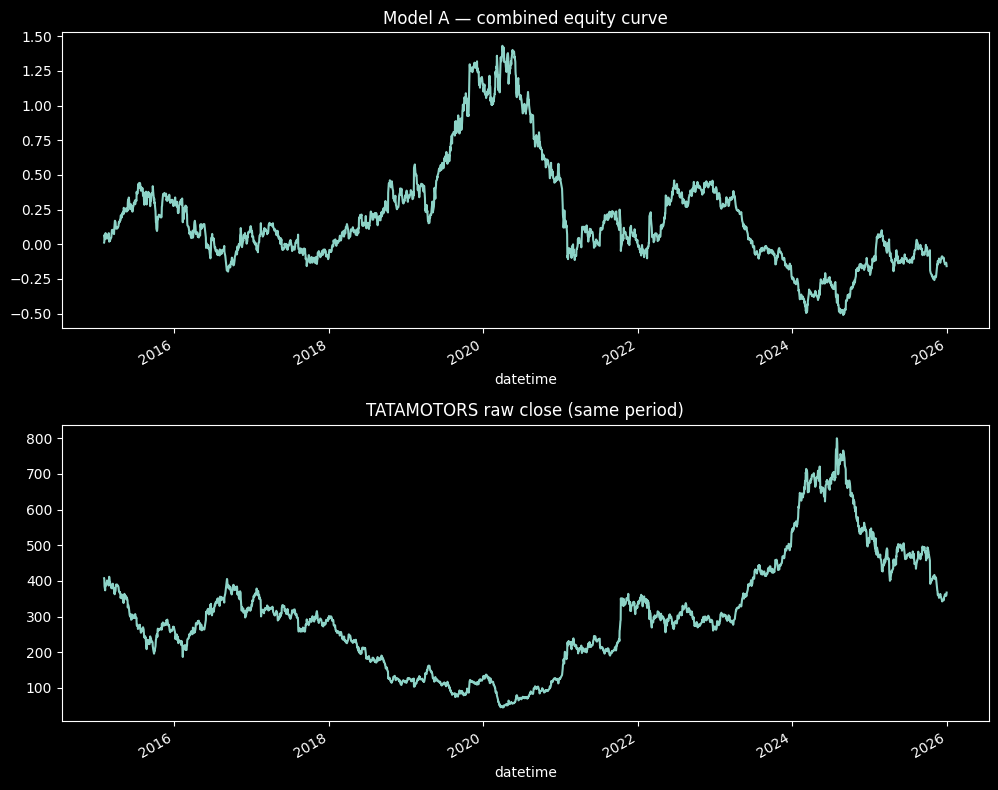

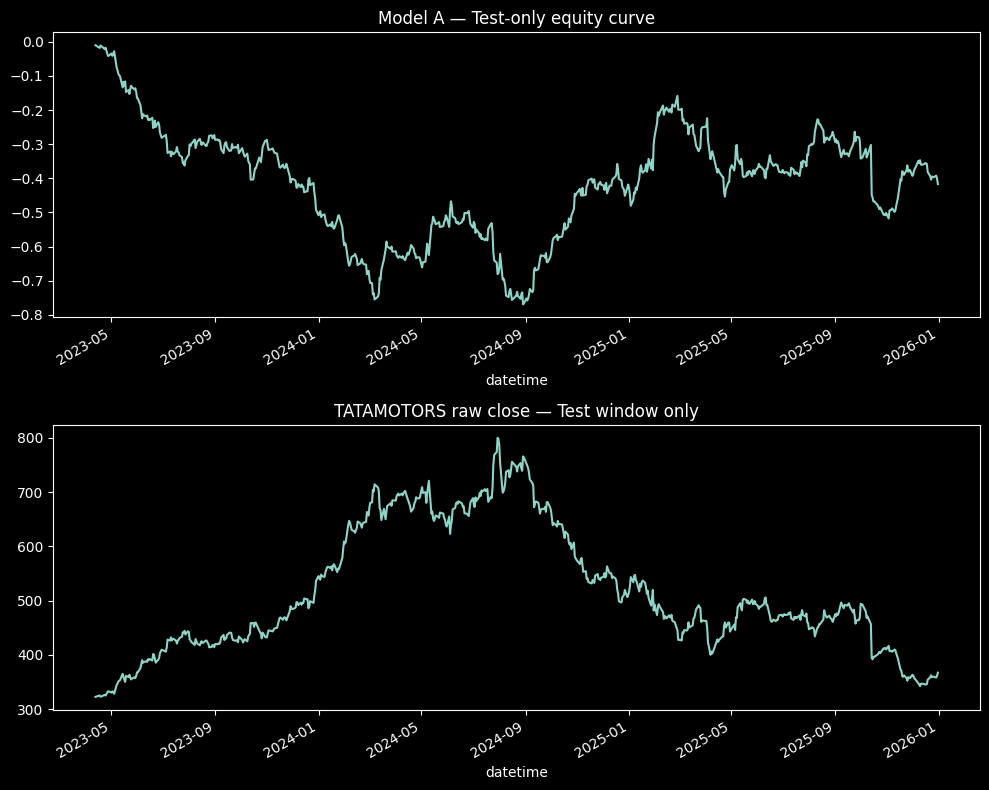

In [10]:
model_a, comb_a, train_a, test_a = train_test_curves(daily, ['close_log_return_lag_1'], 'close_log_return')
print('coef_ =', model_a.coef_, ' intercept_ =', model_a.intercept_)
print()
print('Combined signal value_counts:')
print(comb_a['signal'].value_counts())
print()
print('Combined final cum:', comb_a['cum_trade_log_return'].iloc[-1])
print('Train  final cum:  ', train_a['cum_trade_log_return'].iloc[-1], ' (n=', len(train_a), ')')
print('Test   final cum:  ', test_a['cum_trade_log_return'].iloc[-1], ' (n=', len(test_a), ')')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
comb_a['cum_trade_log_return'].plot(ax=axes[0], title='Model A — combined equity curve')
comb_a['c'].plot(ax=axes[1], title='TATAMOTORS raw close (same period)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_a['cum_trade_log_return'].plot(ax=axes[0], title='Model A — Test-only equity curve')
test_a['c'].plot(ax=axes[1], title='TATAMOTORS raw close — Test window only')
plt.tight_layout()
plt.show()

## MA-alone — 40-day rolling mean of lag_1

df.shape
coef_ = [0.22076604]  intercept_ = -3.6464482782825174e-05

Combined signal value_counts:
signal
-1.0    1407
 1.0    1219
Name: count, dtype: int64

Combined final cum: 3.083715278342512
Train  final cum:   2.558492035838928  (n= 1969 )
Test   final cum:   0.5252232425035874  (n= 657 )


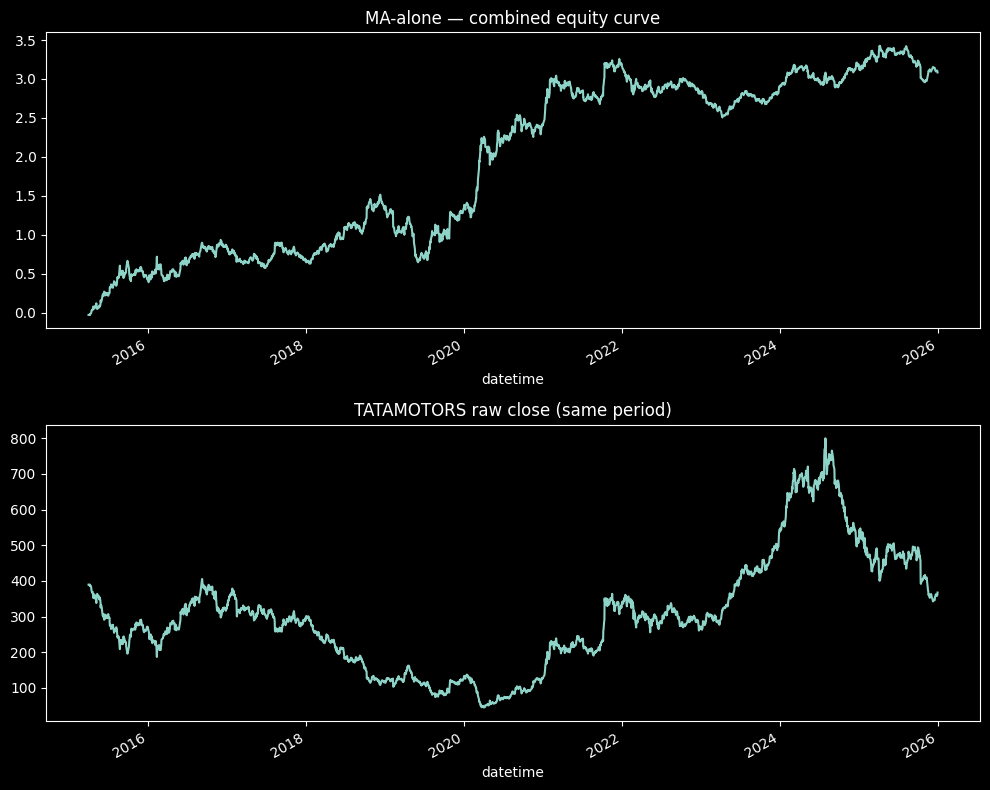

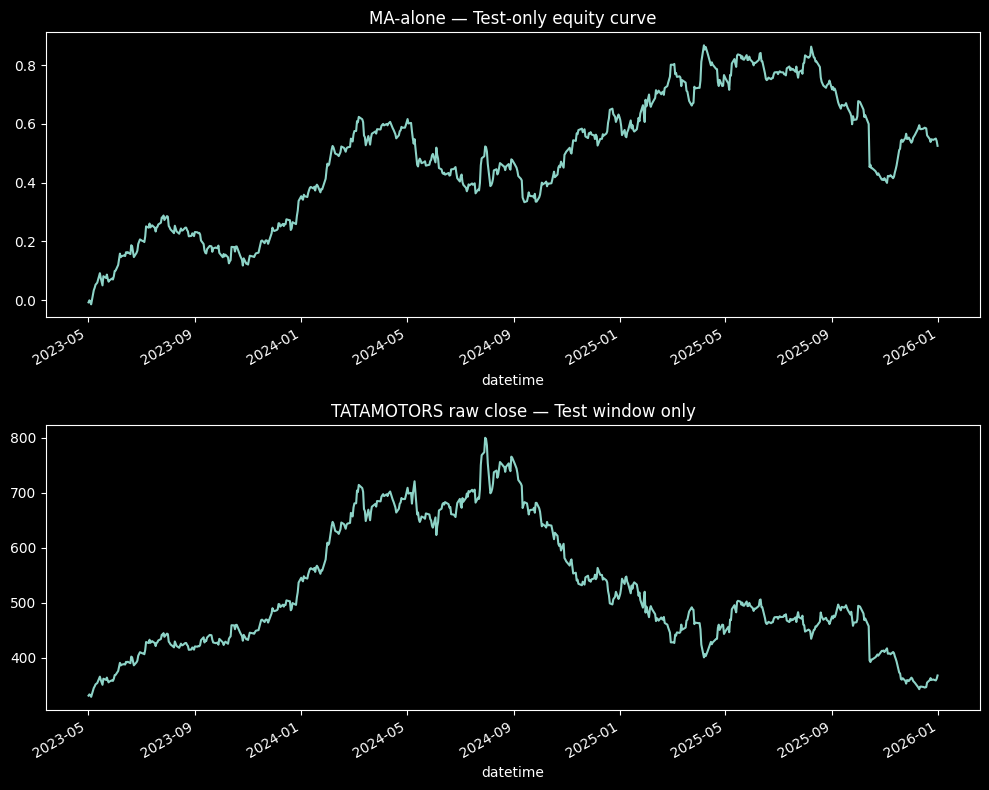

In [5]:
daily['close_log_return_ma_lag_1'] = daily['close_log_return_lag_1'].rolling(40).mean()

model_ma, comb_ma, train_ma, test_ma = train_test_curves(daily, ['close_log_return_ma_lag_1'], 'close_log_return')
print('coef_ =', model_ma.coef_, ' intercept_ =', model_ma.intercept_)
print()
print('Combined signal value_counts:')
print(comb_ma['signal'].value_counts())
print()
print('Combined final cum:', comb_ma['cum_trade_log_return'].iloc[-1])
print('Train  final cum:  ', train_ma['cum_trade_log_return'].iloc[-1], ' (n=', len(train_ma), ')')
print('Test   final cum:  ', test_ma['cum_trade_log_return'].iloc[-1], ' (n=', len(test_ma), ')')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
comb_ma['cum_trade_log_return'].plot(ax=axes[0], title='MA-alone — combined equity curve')
comb_ma['c'].plot(ax=axes[1], title='TATAMOTORS raw close (same period)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_ma['cum_trade_log_return'].plot(ax=axes[0], title='MA-alone — Test-only equity curve')
test_ma['c'].plot(ax=axes[1], title='TATAMOTORS raw close — Test window only')
plt.tight_layout()
plt.show()

## Model B — lag_1 + ma_lag_1 combined

df.shape
coef_ = [-0.01569375  0.23470684]  intercept_ = -3.5559033602467945e-05

Combined signal value_counts:
signal
-1.0    1381
 1.0    1245
Name: count, dtype: int64

Combined final cum: 2.9416196494692755
Train  final cum:   2.082777094487343  (n= 1969 )
Test   final cum:   0.8588425549819348  (n= 657 )


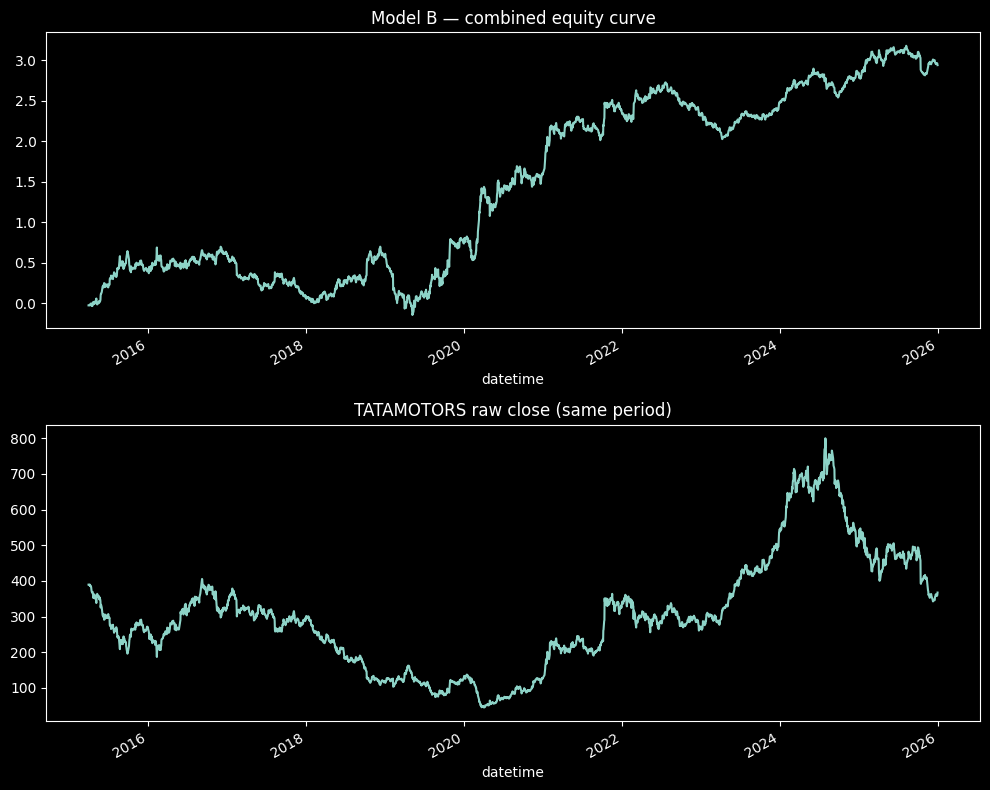

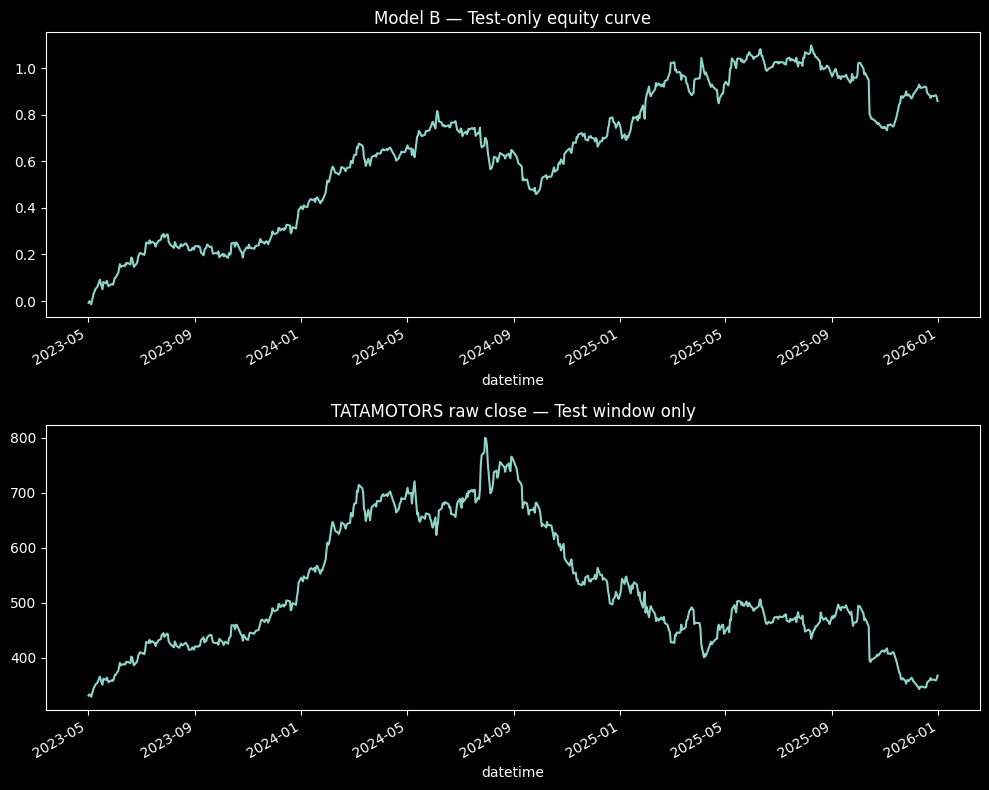

In [6]:
model_b, comb_b, train_b, test_b = train_test_curves(daily, ['close_log_return_lag_1', 'close_log_return_ma_lag_1'], 'close_log_return')
print('coef_ =', model_b.coef_, ' intercept_ =', model_b.intercept_)
print()
print('Combined signal value_counts:')
print(comb_b['signal'].value_counts())
print()
print('Combined final cum:', comb_b['cum_trade_log_return'].iloc[-1])
print('Train  final cum:  ', train_b['cum_trade_log_return'].iloc[-1], ' (n=', len(train_b), ')')
print('Test   final cum:  ', test_b['cum_trade_log_return'].iloc[-1], ' (n=', len(test_b), ')')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
comb_b['cum_trade_log_return'].plot(ax=axes[0], title='Model B — combined equity curve')
comb_b['c'].plot(ax=axes[1], title='TATAMOTORS raw close (same period)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_b['cum_trade_log_return'].plot(ax=axes[0], title='Model B — Test-only equity curve')
test_b['c'].plot(ax=axes[1], title='TATAMOTORS raw close — Test window only')
plt.tight_layout()
plt.show()

## Summary table — Train vs Test cum_trade_log_return, all 3 models

In [7]:
summary = pd.DataFrame({
    'model': ['Model A', 'MA-alone', 'Model B'],
    'train_n': [len(train_a), len(train_ma), len(train_b)],
    'train_cum': [train_a['cum_trade_log_return'].iloc[-1], train_ma['cum_trade_log_return'].iloc[-1], train_b['cum_trade_log_return'].iloc[-1]],
    'test_n': [len(test_a), len(test_ma), len(test_b)],
    'test_cum': [test_a['cum_trade_log_return'].iloc[-1], test_ma['cum_trade_log_return'].iloc[-1], test_b['cum_trade_log_return'].iloc[-1]],
})
summary

,model,train_n,train_cum,test_n,test_cum
0,Model A,1998,0.258721,667,-0.417051
1,MA-alone,1969,2.558492,657,0.525223
2,Model B,1969,2.082777,657,0.858843
